<a href="https://colab.research.google.com/github/oldKiwis/ML_Project_Credit_Card_Fraud_Detection/blob/main/KhanAbdur_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Abdur Khan
#Intro to ML final project

import pandas as pd

# Public hosted copy of the creditcard.csv dataset
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

# Load the data directly from the URL
df = pd.read_csv(url)
print(f"✓ Dataset loaded! Shape: {df.shape}")

# local copy just in case
df.to_csv("creditcard.csv", index=False)

df.head()


✓ Dataset loaded! Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#(for SMOTE)
!pip install imbalanced-learn
# (for advanced models)
!pip install xgboost
# SHAP (for explainability)
!pip install shap



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score, precision_score, recall_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

# style for better-looking plots.
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [ ]:

# Load the dataset
df = pd.read_csv('creditcard.csv')

print("\n1. DATASET OVERVIEW")
print("-" * 80)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nBasic statistics:")
print(df[['Time', 'Amount', 'Class']].describe())


1. DATASET OVERVIEW
--------------------------------------------------------------------------------
Dataset shape: (284807, 31)

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Legitimate transactions: 284,315 (99.83%)
Fraudulent transactions: 492 (0.1727%)
Imbalance ratio: 1:577

Transaction Amount Statistics:
Legitimate - Mean: $88.29, Median: $22.00
Fraudulent - Mean: $122.21, Median: $9.25

✓ Saved: eda_analysis.png


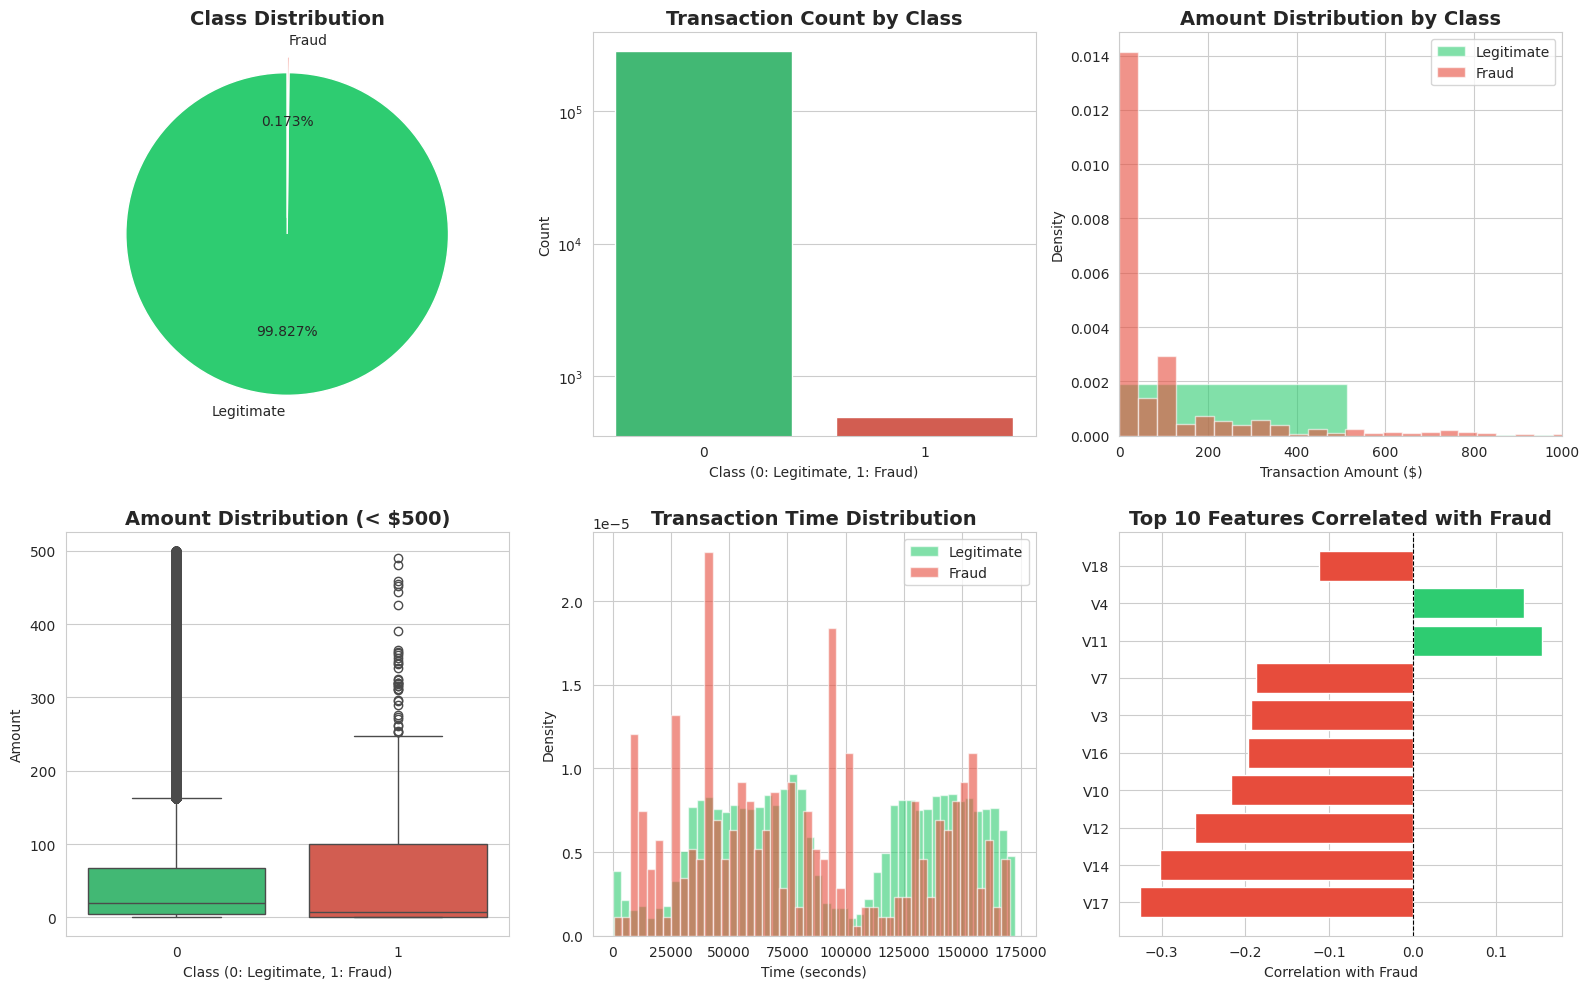

In [ ]:
#Dataset Overview for report purposes

# Class distribution
fraud_count = df['Class'].value_counts()
print(f"\nClass distribution:")
print(fraud_count)
print(f"\nLegitimate transactions: {fraud_count[0]:,} ({fraud_count[0]/len(df)*100:.2f}%)")
print(f"Fraudulent transactions: {fraud_count[1]:,} ({fraud_count[1]/len(df)*100:.4f}%)")
print(f"Imbalance ratio: 1:{int(fraud_count[0]/fraud_count[1])}")

# Statistical comparison
print(f"\nTransaction Amount Statistics:")
print(f"Legitimate - Mean: ${df[df['Class']==0]['Amount'].mean():.2f}, Median: ${df[df['Class']==0]['Amount'].median():.2f}")
print(f"Fraudulent - Mean: ${df[df['Class']==1]['Amount'].mean():.2f}, Median: ${df[df['Class']==1]['Amount'].median():.2f}")

# Visualizations
fig = plt.figure(figsize=(16, 10))

# Class distribution pie chart
plt.subplot(2, 3, 1)
colors = ['#2ecc71', '#e74c3c']
plt.pie(fraud_count.values, labels=['Legitimate', 'Fraud'],
        autopct='%1.3f%%', startangle=90, colors=colors, explode=(0, 0.1))
plt.title('Class Distribution', fontsize=14, fontweight='bold')

# Class distribution bar chart
plt.subplot(2, 3, 2)
sns.countplot(x='Class', data=df, palette=colors)
plt.title('Transaction Count by Class', fontsize=14, fontweight='bold')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Count')
plt.yscale('log')

# Amount distribution
plt.subplot(2, 3, 3)
plt.hist(df[df['Class'] == 0]['Amount'], bins=50, alpha=0.6, label='Legitimate', color='#2ecc71', density=True)
plt.hist(df[df['Class'] == 1]['Amount'], bins=50, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
plt.xlabel('Transaction Amount ($)')
plt.ylabel('Density')
plt.title('Amount Distribution by Class', fontsize=14, fontweight='bold')
plt.legend()
plt.xlim(0, 1000)

# Amount boxplot
plt.subplot(2, 3, 4)
df_plot = df[df['Amount'] < 500]  # Focus on reasonable range
sns.boxplot(x='Class', y='Amount', data=df_plot, palette=colors)
plt.title('Amount Distribution (< $500)', fontsize=14, fontweight='bold')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')

# Time distribution
plt.subplot(2, 3, 5)
plt.hist(df[df['Class'] == 0]['Time'], bins=48, alpha=0.6, label='Legitimate', color='#2ecc71', density=True)
plt.hist(df[df['Class'] == 1]['Time'], bins=48, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
plt.xlabel('Time (seconds)')
plt.ylabel('Density')
plt.title('Transaction Time Distribution', fontsize=14, fontweight='bold')
plt.legend()

# Correlation with fraud
plt.subplot(2, 3, 6)
correlations = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)[:10]
colors_corr = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlations]
plt.barh(range(len(correlations)), correlations.values, color=colors_corr)
plt.yticks(range(len(correlations)), correlations.index)
plt.xlabel('Correlation with Fraud')
plt.title('Top 10 Features Correlated with Fraud', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: eda_analysis.png")
plt.show()


In [ ]:
###
print(" DATA PREPROCESSING")
print("-" * 80)

# Feature scaling for Amount and Time
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original Amount and Time columns
df_scaled = df.drop(['Time', 'Amount'], axis=1)

# Separate features and target
X = df_scaled.drop('Class', axis=1)
y = df_scaled['Class']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")

 DATA PREPROCESSING
--------------------------------------------------------------------------------
Features shape: (284807, 30)
Target shape: (284807,)
Number of features: 30


In [ ]:
# TRAIN-TEST SPLIT
print("TRAIN-TEST SPLIT")
print("-" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]:,}")
print(f"Test set size: {X_test.shape[0]:,}")
print(f"Training set fraud cases: {y_train.sum():,} ({y_train.sum()/len(y_train)*100:.4f}%)")
print(f"Test set fraud cases: {y_test.sum():,} ({y_test.sum()/len(y_test)*100:.4f}%)")


TRAIN-TEST SPLIT
--------------------------------------------------------------------------------
Training set size: 227,845
Test set size: 56,962
Training set fraud cases: 394 (0.1729%)
Test set fraud cases: 98 (0.1720%)


In [ ]:

#HANDLING CLASS IMBALANCE

print("HANDLING CLASS IMBALANCE")
print("-" * 80)

# Strategy: SMOTE (Synthetic Minority Over-sampling Technique)
print("Applying SMOTE to training data...")
smote = SMOTE(random_state=42, sampling_strategy=0.5)  # Create 50% minority to majority ratio
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"After SMOTE:")
print(f"  Training set size: {X_train_smote.shape[0]:,}")
print(f"  Legitimate: {(y_train_smote==0).sum():,}")
print(f"  Fraud: {(y_train_smote==1).sum():,}")
print(f"  New ratio: 1:{(y_train_smote==0).sum()/(y_train_smote==1).sum():.1f}")


HANDLING CLASS IMBALANCE
--------------------------------------------------------------------------------
Applying SMOTE to training data...
After SMOTE:
  Training set size: 341,176
  Legitimate: 227,451
  Fraud: 113,725
  New ratio: 1:2.0


In [ ]:
print("MODEL TRAINING")
print("-" * 80)

models = {}
predictions = {}

# Model 1: Logistic Regression with class weights
print("\n[1/5] Training Logistic Regression (Class Weighted)...")
lr_weighted = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1)
lr_weighted.fit(X_train, y_train)
models['Logistic Regression (Weighted)'] = lr_weighted
predictions['Logistic Regression (Weighted)'] = lr_weighted.predict_proba(X_test)[:, 1]
print("✓ Complete")

# Model 2: Logistic Regression with SMOTE
print("\n[2/5] Training Logistic Regression (SMOTE)...")
lr_smote = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_smote.fit(X_train_smote, y_train_smote)
models['Logistic Regression (SMOTE)'] = lr_smote
predictions['Logistic Regression (SMOTE)'] = lr_smote.predict_proba(X_test)[:, 1]
print("✓ Complete")

# Model 3: Random Forest with class weights
print("\n[3/5] Training Random Forest (Class Weighted)...")
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_weighted.fit(X_train, y_train)
models['Random Forest (Weighted)'] = rf_weighted
predictions['Random Forest (Weighted)'] = rf_weighted.predict_proba(X_test)[:, 1]
print("✓ Complete")

# Model 4: Random Forest with SMOTE
print("\n[4/5] Training Random Forest (SMOTE)...")
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_smote.fit(X_train_smote, y_train_smote)
models['Random Forest (SMOTE)'] = rf_smote
predictions['Random Forest (SMOTE)'] = rf_smote.predict_proba(X_test)[:, 1]
print("✓ Complete")

# Model 5: XGBoost (Advanced)
print("\n[5/5] Training XGBoost (SMOTE)...")
scale_pos_weight = (y_train_smote == 0).sum() / (y_train_smote == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_smote, y_train_smote)
models['XGBoost (SMOTE)'] = xgb_model
predictions['XGBoost (SMOTE)'] = xgb_model.predict_proba(X_test)[:, 1]
print("✓ Complete")

print("\n✓ All 5 models trained successfully!")


MODEL TRAINING
--------------------------------------------------------------------------------

[1/5] Training Logistic Regression (Class Weighted)...
✓ Complete

[2/5] Training Logistic Regression (SMOTE)...
✓ Complete

[3/5] Training Random Forest (Class Weighted)...
✓ Complete

[4/5] Training Random Forest (SMOTE)...
✓ Complete

[5/5] Training XGBoost (SMOTE)...
✓ Complete

✓ All 5 models trained successfully!


In [ ]:

# MODEL EVALUATION

print("MODEL EVALUATION")
print("-" * 80)

results = []

for name, model in models.items():
    print(f"\n{name}")
    print("-" * 80)

    # Predictions
    y_pred_proba = predictions[name]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Neg    Pos")
    print(f"Actual  Neg   [[{tn:5d}  {fp:5d}]]")
    print(f"        Pos   [[{fn:5d}  {tp:5d}]]")

    # Metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    avg_precision = average_precision_score(y_test, y_pred_proba)

    print(f"\nPerformance Metrics:")
    print(f"  Precision:    {precision:.4f} (of predicted frauds, {precision*100:.2f}% were correct)")
    print(f"  Recall:       {recall:.4f} (detected {recall*100:.2f}% of all frauds)")
    print(f"  F1 Score:     {f1:.4f}")
    print(f"  AUC-ROC:      {auc_roc:.4f}")
    print(f"  Avg Precision: {avg_precision:.4f}")

    # metrics
    print(f"Impact:")
    print(f"  True Positives (Caught Frauds):  {tp}")
    print(f"  False Negatives (Missed Frauds): {fn}")
    print(f"  False Positives (False Alarms):  {fp}")
    print(f"  Detection Rate: {tp/(tp+fn)*100:.2f}%")

    # Store results
    results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUC-ROC': auc_roc,
        'Avg Precision': avg_precision,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'y_pred_proba': y_pred_proba
    })


MODEL EVALUATION
--------------------------------------------------------------------------------

Logistic Regression (Weighted)
--------------------------------------------------------------------------------

Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg   [[55475   1389]]
        Pos   [[    8     90]]

Performance Metrics:
  Precision:    0.0609 (of predicted frauds, 6.09% were correct)
  Recall:       0.9184 (detected 91.84% of all frauds)
  F1 Score:     0.1141
  AUC-ROC:      0.9722
  Avg Precision: 0.7189
Impact:
  True Positives (Caught Frauds):  90
  False Negatives (Missed Frauds): 8
  False Positives (False Alarms):  1389
  Detection Rate: 91.84%

Logistic Regression (SMOTE)
--------------------------------------------------------------------------------

Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg   [[56121    743]]
        Pos   [[   10     88]]

Performance Metrics:
  Precision:    0.1059 (o

In [ ]:
print("MODEL IMPROVEMENT TECHNIQUES")
print("Starting from : Random Forest (Weighted) - F1: 0.8081")


#importing again
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, average_precision_score)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# we are starting with random forest weighted since it achived the beset results with 0.80 f1 score. 80% accuaracy and caught majority of the frauds

# Initialize storage for improved models and results
improved_models = {}
improved_results = []

print("\n Initialized: improved_models and improved_results")

# TECHNIQUE 1: THRESHOLD OPTIMIZATION
# Find the optimial threshold to maximize f1 score. Currently we were using defualt value of 0.5.
# Go through the different thresholds and find which one gives the best f1 score

print("TECHNIQUE 1: THRESHOLD OPTIMIZATION")
print('-' * 80)

# Access from models dictionary created in model evaluation
best_model = models['Random Forest (Weighted)']
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\nTesting thresholds from 0.20 to 0.60...")

# Test thresholds
thresholds_to_test = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
threshold_results = []

for threshold in thresholds_to_test:
    y_pred_thresh = (y_pred_proba_best >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    cm = confusion_matrix(y_test, y_pred_thresh)

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'tp': cm[1,1],
        'fp': cm[0,1],
        'fn': cm[1,0],
        'tn': cm[0,0]
    })

threshold_df = pd.DataFrame(threshold_results)
print("\nThreshold Analysis:")
print(threshold_df[['threshold', 'precision', 'recall', 'f1_score', 'tp', 'fp', 'fn']].to_string(index=False))

# Find optimal threshold for F1
best_f1_idx = threshold_df['f1_score'].idxmax()
optimal_threshold = threshold_df.loc[best_f1_idx, 'threshold']

# Get predictions at optimal threshold
y_pred_threshold_opt = (y_pred_proba_best >= optimal_threshold).astype(int)

# Calculate all metrics at optimal threshold
precision_thresh = threshold_df.loc[best_f1_idx, 'precision']
recall_thresh = threshold_df.loc[best_f1_idx, 'recall']
f1_thresh = threshold_df.loc[best_f1_idx, 'f1_score']
auc_roc_thresh = roc_auc_score(y_test, y_pred_proba_best)  # AUC-ROC doesn't change with threshold
avg_precision_thresh = average_precision_score(y_test, y_pred_proba_best)  # Avg Precision doesn't change with threshold
cm_thresh = confusion_matrix(y_test, y_pred_threshold_opt)
tn_t, fp_t, fn_t, tp_t = cm_thresh.ravel()

print("THRESHOLD OPTIMIZATION - DETAILED EVALUATION")
print(f"OPTIMAL THRESHOLD: {optimal_threshold}")
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Neg    Pos")
print(f"Actual  Neg   [[{tn_t:5d}  {fp_t:5d}]]")
print(f"        Pos   [[{fn_t:5d}  {tp_t:5d}]]")

print(f"\nPerformance Metrics:")
print(f"  Precision:     {precision_thresh:.4f} (of predicted frauds, {precision_thresh*100:.2f}% were correct)")
print(f"  Recall:        {recall_thresh:.4f} (detected {recall_thresh*100:.2f}% of all frauds)")
print(f"  F1 Score:      {f1_thresh:.4f}")
print(f"  AUC-ROC:       {auc_roc_thresh:.4f}")
print(f"  Avg Precision: {avg_precision_thresh:.4f}")

print(f"Impact:")
print(f"  True Positives (Caught Frauds):  {tp_t}")
print(f"  False Negatives (Missed Frauds): {fn_t}")
print(f"  False Positives (False Alarms):  {fp_t}")
print(f"  Detection Rate: {tp_t/(tp_t+fn_t)*100:.2f}%")

improvement_thresh = ((f1_thresh - 0.8081) / 0.8081) * 100
print(f"Improvement over original: {improvement_thresh:+.2f}%")

# Store results
improved_models['RF Threshold Optimized'] = best_model  # Same model, different threshold
improved_results.append({
    'Model': 'RF (Threshold Optimized)',
    'Technique': f'Threshold={optimal_threshold}',
    'Precision': precision_thresh,
    'Recall': recall_thresh,
    'F1 Score': f1_thresh,
    'AUC-ROC': auc_roc_thresh,
    'Avg Precision': avg_precision_thresh,
    'TP': tp_t,
    'FP': fp_t,
    'FN': fn_t,
    'TN': tn_t,
    'y_pred_proba': y_pred_proba_best,
    'threshold': optimal_threshold
})

MODEL IMPROVEMENT TECHNIQUES
Starting from : Random Forest (Weighted) - F1: 0.8081

 Initialized: improved_models and improved_results
TECHNIQUE 1: THRESHOLD OPTIMIZATION
--------------------------------------------------------------------------------

Testing thresholds from 0.20 to 0.60...

Threshold Analysis:
 threshold  precision   recall  f1_score  tp  fp  fn
      0.20   0.369748 0.897959  0.523810  88 150  10
      0.25   0.469945 0.877551  0.612100  86  97  12
      0.30   0.541401 0.867347  0.666667  85  72  13
      0.35   0.613139 0.857143  0.714894  84  53  14
      0.40   0.664000 0.846939  0.744395  83  42  15
      0.45   0.729730 0.826531  0.775120  81  30  17
      0.50   0.800000 0.816327  0.808081  80  20  18
      0.55   0.833333 0.816327  0.824742  80  16  18
      0.60   0.838710 0.795918  0.816754  78  15  20
THRESHOLD OPTIMIZATION - DETAILED EVALUATION
OPTIMAL THRESHOLD: 0.55

Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg  

In [ ]:
# Optimized Technique: ENSEMBLE STACKING
print("TECHNIQUE: ENSEMBLE STACKING")
# we try to combine multiple models for better predeictions. Different models can make different errors.
# we use meta learner to help the model learn when to trust what


print("\nBuilding stacked ensemble:")
print("  • Base Model 1: Random Forest (tree-based)")
print("  • Base Model 2: XGBoost (gradient boosting)")
print("  • Base Model 3: Logistic Regression (linear)")
print("  • Meta-Learner: Logistic Regression (combines predictions)")

# Calculate scale_pos_weight for XGBoost
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Base models
base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )),
    ('xgb', xgb.XGBClassifier(
        n_estimators=100,
        max_depth=5,
        scale_pos_weight=scale_weight,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
]

# Meta-learner
meta_learner = LogisticRegression(max_iter=1000)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=3,
    n_jobs=-1
)

stacking_clf.fit(X_train, y_train)

# Predictions
y_pred_stack = stacking_clf.predict(X_test)
y_pred_proba_stack = stacking_clf.predict_proba(X_test)[:, 1]

# Calculate all metrics
precision_stack = precision_score(y_test, y_pred_stack)
recall_stack = recall_score(y_test, y_pred_stack)
f1_stack = f1_score(y_test, y_pred_stack)
auc_roc_stack = roc_auc_score(y_test, y_pred_proba_stack)
avg_precision_stack = average_precision_score(y_test, y_pred_proba_stack)
cm_stack = confusion_matrix(y_test, y_pred_stack)
tn_s, fp_s, fn_s, tp_s = cm_stack.ravel()

print("STACKED ENSEMBLE - DETAILED EVALUATION")

print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Neg    Pos")
print(f"Actual  Neg   [[{tn_s:5d}  {fp_s:5d}]]")
print(f"        Pos   [[{fn_s:5d}  {tp_s:5d}]]")

print(f"\nPerformance Metrics:")
print(f"  Precision:     {precision_stack:.4f} (of predicted frauds, {precision_stack*100:.2f}% were correct)")
print(f"  Recall:        {recall_stack:.4f} (detected {recall_stack*100:.2f}% of all frauds)")
print(f"  F1 Score:      {f1_stack:.4f}")
print(f"  AUC-ROC:       {auc_roc_stack:.4f}")
print(f"  Avg Precision: {avg_precision_stack:.4f}")

print(f"Impact:")
print(f"  True Positives (Caught Frauds):  {tp_s}")
print(f"  False Negatives (Missed Frauds): {fn_s}")
print(f"  False Positives (False Alarms):  {fp_s}")
print(f"  Detection Rate: {tp_s/(tp_s+fn_s)*100:.2f}%")

improvement_stack = ((f1_stack - 0.8081) / 0.8081) * 100
print(f"Improvement over original: {improvement_stack:+.2f}%")

# Store results
improved_models['Stacked Ensemble'] = stacking_clf
improved_results.append({
    'Model': 'Stacked Ensemble',
    'Technique': 'RF+XGB+LR Stack',
    'Precision': precision_stack,
    'Recall': recall_stack,
    'F1 Score': f1_stack,
    'AUC-ROC': auc_roc_stack,
    'Avg Precision': avg_precision_stack,
    'TP': tp_s,
    'FP': fp_s,
    'FN': fn_s,
    'TN': tn_s,
    'y_pred_proba': y_pred_proba_stack,
    'threshold': 0.5
})

TECHNIQUE: ENSEMBLE STACKING

Building stacked ensemble:
  • Base Model 1: Random Forest (tree-based)
  • Base Model 2: XGBoost (gradient boosting)
  • Base Model 3: Logistic Regression (linear)
  • Meta-Learner: Logistic Regression (combines predictions)
STACKED ENSEMBLE - DETAILED EVALUATION

Confusion Matrix:
                 Predicted
                 Neg    Pos
Actual  Neg   [[56855      9]]
        Pos   [[   17     81]]

Performance Metrics:
  Precision:     0.9000 (of predicted frauds, 90.00% were correct)
  Recall:        0.8265 (detected 82.65% of all frauds)
  F1 Score:      0.8617
  AUC-ROC:       0.9750
  Avg Precision: 0.8572
Impact:
  True Positives (Caught Frauds):  81
  False Negatives (Missed Frauds): 17
  False Positives (False Alarms):  9
  Detection Rate: 82.65%
Improvement over original: +6.63%


COMPREHENSIVE PERFORMANCE COMPARISON
COMPLETE PERFORMANCE METRICS TABLE:
                   Model  Precision   Recall  F1 Score  AUC-ROC  Avg Precision
  Original RF (Weighted)   0.800000 0.816300  0.808100 0.971400       0.809300
RF (Threshold Optimized)   0.833333 0.816327  0.824742 0.971388       0.809280
        Stacked Ensemble   0.900000 0.826531  0.861702 0.975028       0.857193
CONFUSION MATRIX COMPARISON:
                   Model  TP  FP  FN    TN
  Original RF (Weighted)  80  20  18 56844
RF (Threshold Optimized)  80  16  18 56848
        Stacked Ensemble  81   9  17 56855
METRIC CHANGES FROM BASELINE: 
                   Model  F1 Improvement  Precision Change  Recall Change
  Original RF (Weighted)            0.00              0.00           0.00
RF (Threshold Optimized)            2.06              3.33           0.00
        Stacked Ensemble            6.63             10.00           1.02
BEST PERFORMERS BY METRIC
BEST F1 SCORE: Stacked Ensemble
   F1 Score: 0.8617
   Pr

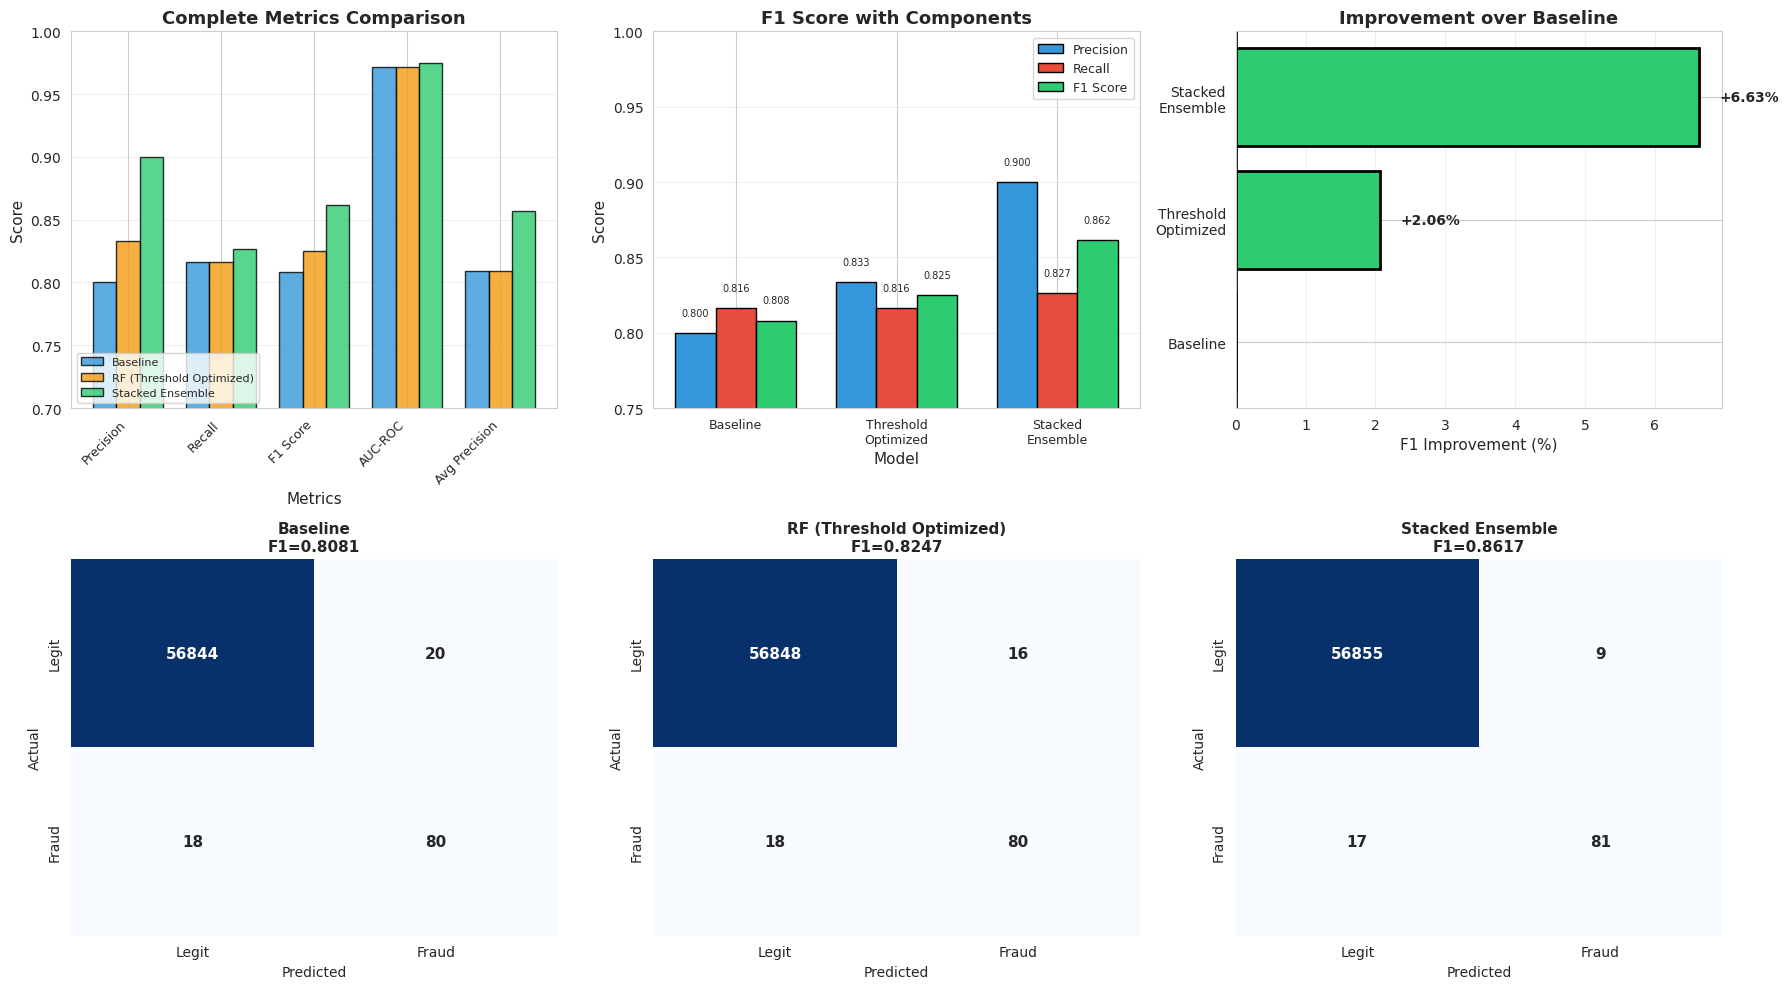

In [ ]:
# COMPREHENSIVE COMPARISON WITH ALL METRICS

print("COMPREHENSIVE PERFORMANCE COMPARISON")

# Add original baseline
all_results = [{
    'Model': 'Original RF (Weighted)',
    'Technique': 'Class Weighting (Baseline)',
    'Precision': 0.8000,
    'Recall': 0.8163,
    'F1 Score': 0.8081,
    'AUC-ROC': 0.9714,
    'Avg Precision': 0.8093,
    'TP': 80,
    'FP': 20,
    'FN': 18,
    'TN': 56844,
    'threshold': 0.5
}] + improved_results

comparison_df = pd.DataFrame(all_results)

# Display full comparison table
print("COMPLETE PERFORMANCE METRICS TABLE:")
display_cols = ['Model', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC', 'Avg Precision']
print(comparison_df[display_cols].to_string(index=False))

print("CONFUSION MATRIX COMPARISON:")
cm_display_cols = ['Model', 'TP', 'FP', 'FN', 'TN']
print(comparison_df[cm_display_cols].to_string(index=False))

# Calculate improvements
comparison_df['F1 Improvement'] = ((comparison_df['F1 Score'] - 0.8081) / 0.8081 * 100).round(2)
comparison_df['Precision Change'] = ((comparison_df['Precision'] - 0.8000) * 100).round(2)
comparison_df['Recall Change'] = ((comparison_df['Recall'] - 0.8163) * 100).round(2)

print("METRIC CHANGES FROM BASELINE: ")
change_cols = ['Model', 'F1 Improvement', 'Precision Change', 'Recall Change']
print(comparison_df[change_cols].to_string(index=False))

# Find best performers
best_f1_model = comparison_df.loc[comparison_df['F1 Score'].idxmax()]
best_precision_model = comparison_df.loc[comparison_df['Precision'].idxmax()]
best_recall_model = comparison_df.loc[comparison_df['Recall'].idxmax()]
best_auc_model = comparison_df.loc[comparison_df['AUC-ROC'].idxmax()]

print("BEST PERFORMERS BY METRIC")

print(f"BEST F1 SCORE: {best_f1_model['Model']}")
print(f"   F1 Score: {best_f1_model['F1 Score']:.4f}")
print(f"   Precision: {best_f1_model['Precision']:.4f}, Recall: {best_f1_model['Recall']:.4f}")
print(f"   AUC-ROC: {best_f1_model['AUC-ROC']:.4f}, Avg Precision: {best_f1_model['Avg Precision']:.4f}")
print(f"   Frauds Caught: {int(best_f1_model['TP'])}/98, False Alarms: {int(best_f1_model['FP'])}")

print(f"BEST PRECISION: {best_precision_model['Model']}")
print(f"   Precision: {best_precision_model['Precision']:.4f} ({best_precision_model['Precision']*100:.2f}%)")
print(f"   False Alarms: {int(best_precision_model['FP'])}")

print(f"BEST RECALL: {best_recall_model['Model']}")
print(f"   Recall: {best_recall_model['Recall']:.4f} ({best_recall_model['Recall']*100:.2f}%)")
print(f"   Frauds Caught: {int(best_recall_model['TP'])}/98")

print(f"BEST AUC-ROC: {best_auc_model['Model']}")
print(f"   AUC-ROC: {best_auc_model['AUC-ROC']:.4f}")

# ENHANCED VISUALIZATIONS For report and visuals
print("GENERATING ENHANCED COMPARISON VISUALIZATIONS")

# Filter out Gradient Boosting for visualization (poor performer)
comparison_df_viz = comparison_df[comparison_df['Model'] != 'Gradient Boosting'].copy()

fig = plt.figure(figsize=(18, 10))

# Plot 1: All Metrics Comparison
plt.subplot(2, 3, 1)
metrics = ['Precision', 'Recall', 'F1 Score', 'AUC-ROC', 'Avg Precision']
x_pos = np.arange(len(metrics))
width = 0.25

colors_bar = ['#3498db', '#f39c12', '#2ecc71']
for i, (_, row) in enumerate(comparison_df_viz.iterrows()):
    values = [row['Precision'], row['Recall'], row['F1 Score'], row['AUC-ROC'], row['Avg Precision']]
    plt.bar(x_pos + i*width, values, width, label=row['Model'].replace(' (Weighted)', '').replace('Original RF', 'Baseline'),
            color=colors_bar[i], edgecolor='black', linewidth=1, alpha=0.8)

plt.xlabel('Metrics', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.title('Complete Metrics Comparison', fontsize=13, fontweight='bold')
plt.xticks(x_pos + width, metrics, rotation=45, ha='right', fontsize=9)
plt.ylim(0.70, 1.0)
plt.legend(fontsize=8, loc='lower left')
plt.grid(True, alpha=0.3, axis='y')

# Plot 2: F1 Score with Components
plt.subplot(2, 3, 2)
models_short = ['Baseline', 'Threshold\nOptimized', 'Stacked\nEnsemble']
f1_scores = comparison_df_viz['F1 Score'].values
precisions = comparison_df_viz['Precision'].values
recalls = comparison_df_viz['Recall'].values

x = np.arange(len(models_short))
width_bar = 0.25

bars1 = plt.bar(x - width_bar, precisions, width_bar, label='Precision', color='#3498db', edgecolor='black', linewidth=1)
bars2 = plt.bar(x, recalls, width_bar, label='Recall', color='#e74c3c', edgecolor='black', linewidth=1)
bars3 = plt.bar(x + width_bar, f1_scores, width_bar, label='F1 Score', color='#2ecc71', edgecolor='black', linewidth=1)

plt.xlabel('Model', fontsize=11)
plt.ylabel('Score', fontsize=11)
plt.title('F1 Score with Components', fontsize=13, fontweight='bold')
plt.xticks(x, models_short, fontsize=9)
plt.ylim(0.75, 1.0)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=7)

# Plot 3: Confusion Matrices (only for 3 good models)
for idx, (i, row) in enumerate(comparison_df_viz.iterrows()):
    plt.subplot(2, 3, idx + 4)
    cm = np.array([[row['TN'], row['FP']], [row['FN'], row['TP']]])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'],
                annot_kws={'size': 11, 'weight': 'bold'})
    model_name = row['Model'].replace('Original RF (Weighted)', 'Baseline')
    plt.title(f'{model_name}\nF1={row["F1 Score"]:.4f}', fontsize=11, fontweight='bold')
    plt.ylabel('Actual', fontsize=10)
    plt.xlabel('Predicted', fontsize=10)

# Plot 4: Improvement Percentages
plt.subplot(2, 3, 3)
improvements = comparison_df_viz['F1 Improvement'].values
colors_imp = ['gray' if imp == 0 else '#2ecc71' if imp > 0 else '#e74c3c' for imp in improvements]
bars = plt.barh(range(len(models_short)), improvements, color=colors_imp, edgecolor='black', linewidth=2)
plt.yticks(range(len(models_short)), models_short, fontsize=10)
plt.xlabel('F1 Improvement (%)', fontsize=11)
plt.title('Improvement over Baseline', fontsize=13, fontweight='bold')
for i, (bar, imp) in enumerate(zip(bars, improvements)):
    if imp != 0:
        plt.text(imp + 0.3 if imp > 0 else imp - 0.3, i, f'{imp:+.2f}%',
                va='center', ha='left' if imp > 0 else 'right', fontsize=10, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.axvline(x=0, color='black', linewidth=2)

plt.tight_layout()
plt.savefig('final_model_improvement_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: final_model_improvement_comparison.png")
plt.show()


VISUALIZATION OF RESULTS
✓ Saved: model_comparison_comprehensive.png


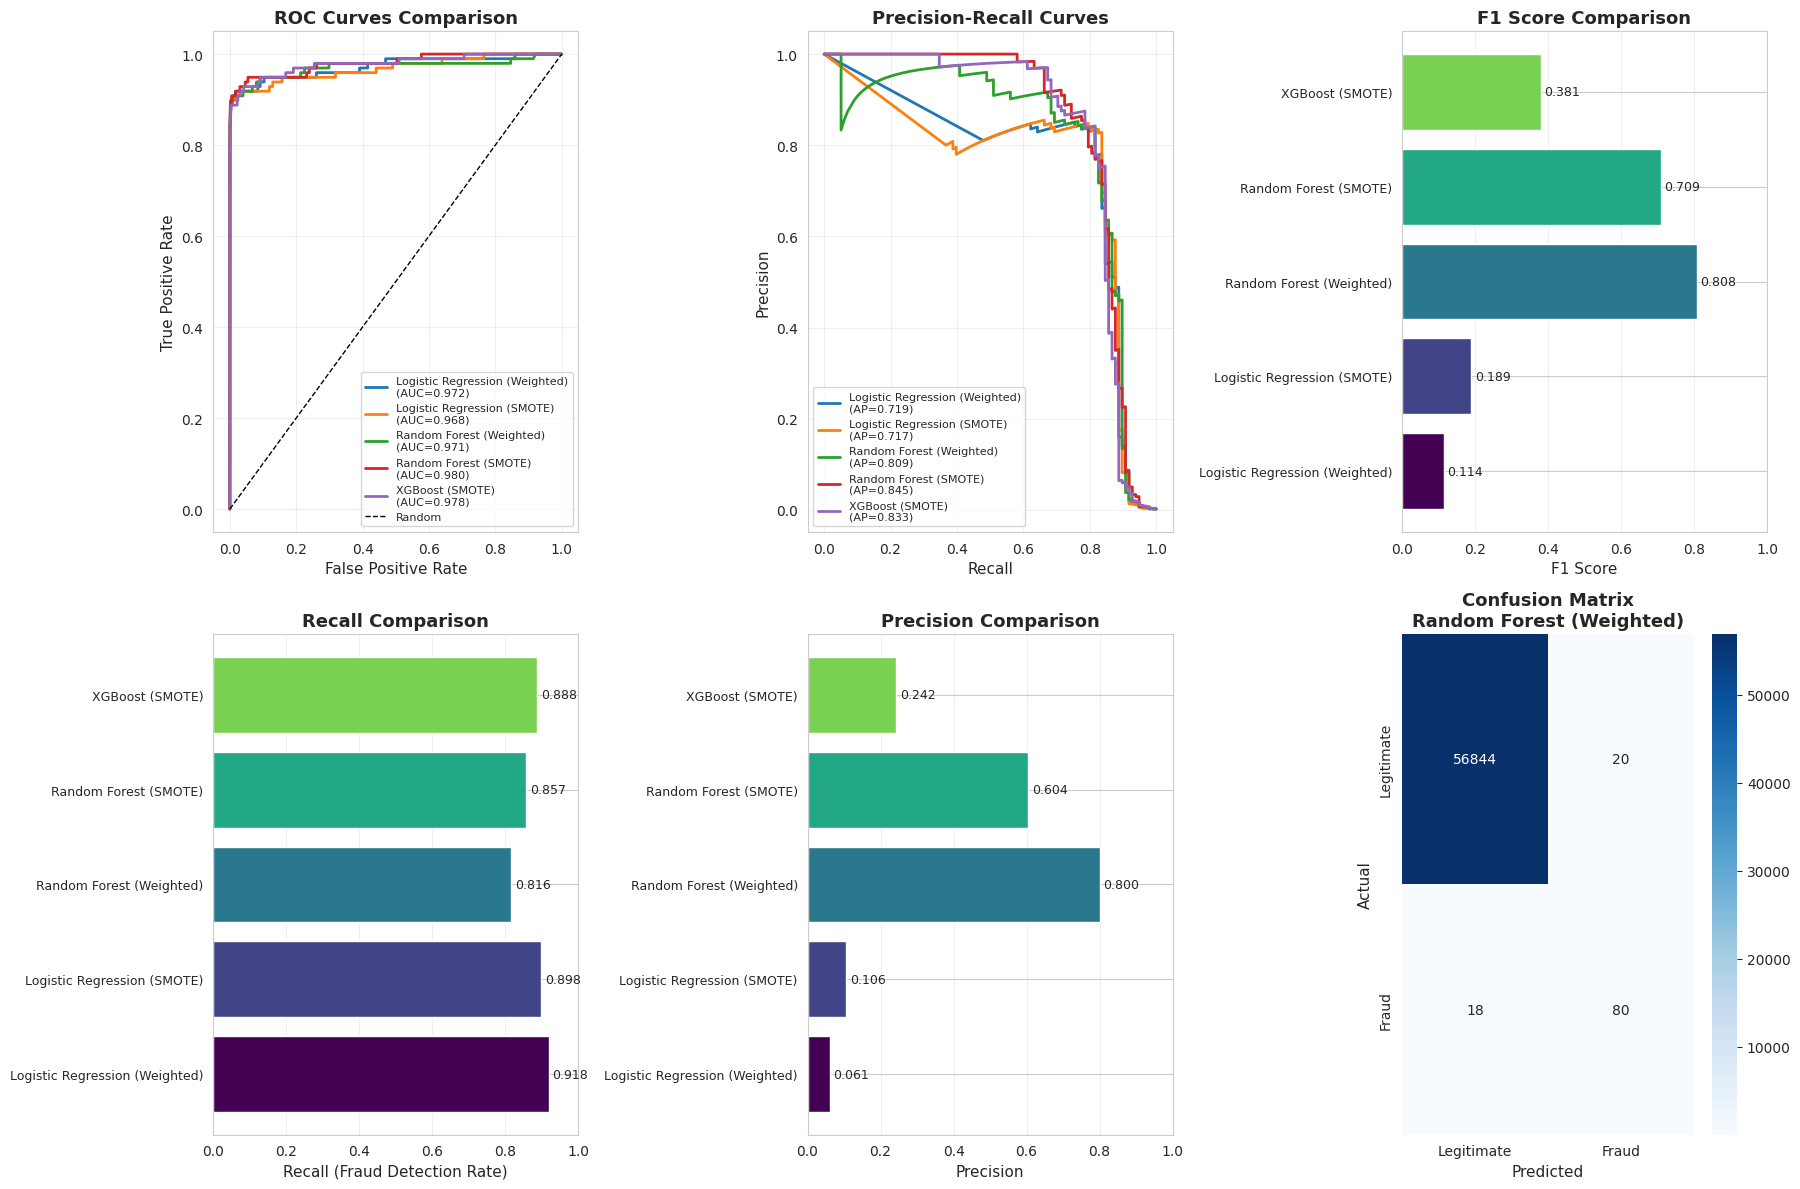


MODEL PERFORMANCE SUMMARY
                         Model  Precision   Recall  F1 Score  AUC-ROC  Avg Precision
Logistic Regression (Weighted)   0.060852 0.918367  0.114141 0.972167       0.718946
   Logistic Regression (SMOTE)   0.105897 0.897959  0.189451 0.968146       0.717142
      Random Forest (Weighted)   0.800000 0.816327  0.808081 0.971388       0.809280
         Random Forest (SMOTE)   0.604317 0.857143  0.708861 0.979765       0.845339
               XGBoost (SMOTE)   0.242340 0.887755  0.380744 0.978133       0.832759


In [ ]:
#VISUALIZATION OF RESULTS
print("VISUALIZATION OF RESULTS")

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))

# ROC Curves
plt.subplot(2, 3, 1)
for result in results:
    fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{result['Model']}\n(AUC={result['AUC-ROC']:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves Comparison', fontsize=13, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# Precision-Recall Curves
plt.subplot(2, 3, 2)
for result in results:
    precision, recall, _ = precision_recall_curve(y_test, result['y_pred_proba'])
    plt.plot(recall, precision, label=f"{result['Model']}\n(AP={result['Avg Precision']:.3f})", linewidth=2)
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Precision-Recall Curves', fontsize=13, fontweight='bold')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

# F1 Score Comparison
plt.subplot(2, 3, 3)
model_names = [r['Model'] for r in results]
f1_scores = [r['F1 Score'] for r in results]
colors_f1 = plt.cm.viridis(np.linspace(0, 0.8, len(results)))
bars = plt.barh(range(len(model_names)), f1_scores, color=colors_f1)
plt.yticks(range(len(model_names)), model_names, fontsize=9)
plt.xlabel('F1 Score', fontsize=11)
plt.title('F1 Score Comparison', fontsize=13, fontweight='bold')
plt.xlim(0, 1)
for i, (bar, score) in enumerate(zip(bars, f1_scores)):
    plt.text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')

# Recall Comparison
plt.subplot(2, 3, 4)
recalls = [r['Recall'] for r in results]
bars = plt.barh(range(len(model_names)), recalls, color=colors_f1)
plt.yticks(range(len(model_names)), model_names, fontsize=9)
plt.xlabel('Recall (Fraud Detection Rate)', fontsize=11)
plt.title('Recall Comparison', fontsize=13, fontweight='bold')
plt.xlim(0, 1)
for i, (bar, score) in enumerate(zip(bars, recalls)):
    plt.text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')

# Precision Comparison
plt.subplot(2, 3, 5)
precisions = [r['Precision'] for r in results]
bars = plt.barh(range(len(model_names)), precisions, color=colors_f1)
plt.yticks(range(len(model_names)), model_names, fontsize=9)
plt.xlabel('Precision', fontsize=11)
plt.title('Precision Comparison', fontsize=13, fontweight='bold')
plt.xlim(0, 1)
for i, (bar, score) in enumerate(zip(bars, precisions)):
    plt.text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')

# Confusion Matrix for Best Model
plt.subplot(2, 3, 6)
best_idx = max(range(len(results)), key=lambda i: results[i]['F1 Score'])
best_result = results[best_idx]
cm_best = np.array([[best_result['TN'], best_result['FP']],
                    [best_result['FN'], best_result['TP']]])
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title(f'Confusion Matrix\n{best_result["Model"]}', fontsize=13, fontweight='bold')
plt.ylabel('Actual', fontsize=11)
plt.xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison_comprehensive.png', dpi=300, bbox_inches='tight')
print("✓ Saved: model_comparison_comprehensive.png")
plt.show()

# Performance summary table
results_df = pd.DataFrame(results)[['Model', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC', 'Avg Precision']]
print("\n" + "=" * 80)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 80)
print(results_df.to_string(index=False))


FEATURE IMPORTANCE ANALYSIS

Random Forest Feature Importance (Top 15):
Feature  Importance
    V14    0.244091
    V10    0.123460
    V17    0.121329
     V4    0.090677
    V12    0.081005
    V11    0.070483
     V3    0.062228
    V16    0.050301
     V7    0.027058
     V2    0.023794
     V9    0.011942
    V21    0.010405
    V27    0.010290
     V8    0.007998
    V19    0.006644

XGBoost Feature Importance (Top 15):
      Feature  Importance
          V14    0.499727
           V4    0.054297
           V8    0.038312
          V12    0.036159
          V18    0.023624
          V13    0.022483
          V26    0.019466
scaled_amount    0.019461
  scaled_time    0.019290
           V3    0.018178
          V10    0.017690
          V25    0.016663
           V1    0.016620
          V17    0.016065
          V22    0.015408

✓ Saved: feature_importance_comparison.png


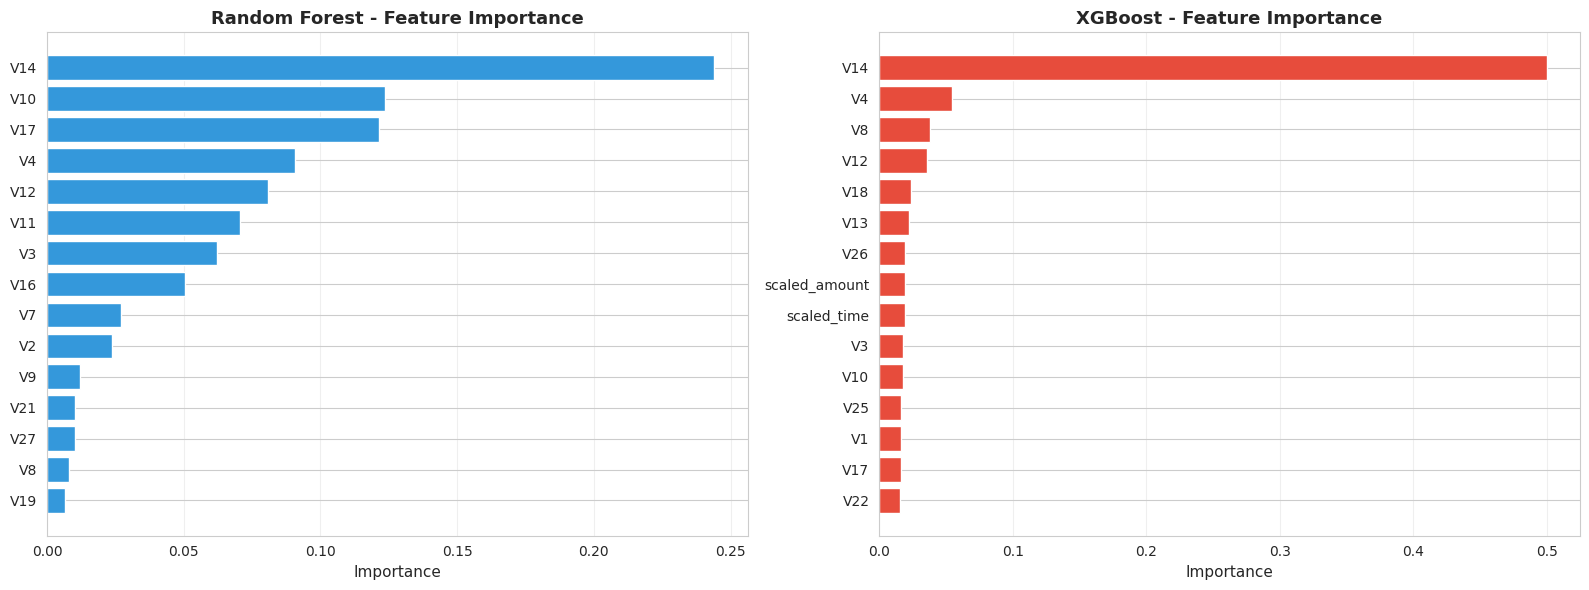

In [ ]:
#FEATURE IMPORTANCE ANALYSIS
print("FEATURE IMPORTANCE ANALYSIS")


# Random Forest Feature Importance
print("\nRandom Forest Feature Importance (Top 15):")
rf_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_smote.feature_importances_
}).sort_values('Importance', ascending=False)
print(rf_feature_importance.head(15).to_string(index=False))

# XGBoost Feature Importance
print("\nXGBoost Feature Importance (Top 15):")
xgb_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
print(xgb_feature_importance.head(15).to_string(index=False))

# Visualize Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
top_rf = rf_feature_importance.head(15)
axes[0].barh(range(len(top_rf)), top_rf['Importance'], color='#3498db')
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf['Feature'])
axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title('Random Forest - Feature Importance', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# XGBoost
top_xgb = xgb_feature_importance.head(15)
axes[1].barh(range(len(top_xgb)), top_xgb['Importance'], color='#e74c3c')
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb['Feature'])
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title('XGBoost - Feature Importance', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: feature_importance_comparison.png")
plt.show()
